In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Data Loading and Cleaning

In [2]:
# Load dataset
file_path = "https://raw.githubusercontent.com/josephakpro/Financial_Forecasting/refs/heads/main/Dataset/Raw/financial_forecasting_dataset.csv"
df = pd.read_csv(file_path)

# Convert Date to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# Set frequency (Assuming monthly start 'MS' based on standard financial periods. Adjust if daily 'D')
df = df.asfreq('MS')

# Forward-fill missing values to prevent breaks in the time series
df = df.ffill()

# Display basic information
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicated Rows:", df.duplicated().sum())

Data Types:
 Loan Applications        int64
Approved Loans           int64
Rejected Loans           int64
Approval Rate          float64
Average Loan Amount    float64
Total Loan Value       float64
Default Rate           float64
Revenue                float64
Interest Rate          float64
Inflation Rate         float64
Unemployment Rate      float64
GDP Growth             float64
Consumer Confidence    float64
Marketing Spend        float64
dtype: object

Missing Values:
 Loan Applications      0
Approved Loans         0
Rejected Loans         0
Approval Rate          0
Average Loan Amount    0
Total Loan Value       0
Default Rate           0
Revenue                0
Interest Rate          0
Inflation Rate         0
Unemployment Rate      0
GDP Growth             0
Consumer Confidence    0
Marketing Spend        0
dtype: int64

Duplicated Rows: 0


In [3]:
display(df.head())

,Loan Applications,Approved Loans,Rejected Loans,Approval Rate,Average Loan Amount,Total Loan Value,Default Rate,Revenue,Interest Rate,Inflation Rate,Unemployment Rate,GDP Growth,Consumer Confidence,Marketing Spend
Date,,,,,,,,,,,,,,
2015-01-01,6294,4560,1734,0.724532,14987.222965,6.834174e+07,0.092119,3.417087e+06,4.099343,2.181309,4.936858,1.314746,90.779168,97131.689966
2015-02-01,6189,4159,2030,0.672156,15636.364510,6.503164e+07,0.082539,3.251582e+06,4.027874,2.725315,4.738033,2.541549,87.953223,98065.705294
2015-03-01,6437,4401,2036,0.683742,15371.800077,6.765129e+07,0.095606,3.382565e+06,4.240420,2.390069,5.507936,1.954184,93.245164,101436.233649
2015-04-01,6992,4961,2031,0.709625,14964.692834,7.423984e+07,0.081249,3.711992e+06,4.470502,3.212384,4.791903,2.495127,87.002133,99682.876144
2015-05-01,6810,4974,1836,0.730424,15585.849355,7.752401e+07,0.087880,3.876201e+06,4.173567,2.592219,5.088658,1.362229,92.436935,99635.771087


Exploratory Data Analysis (EDA)

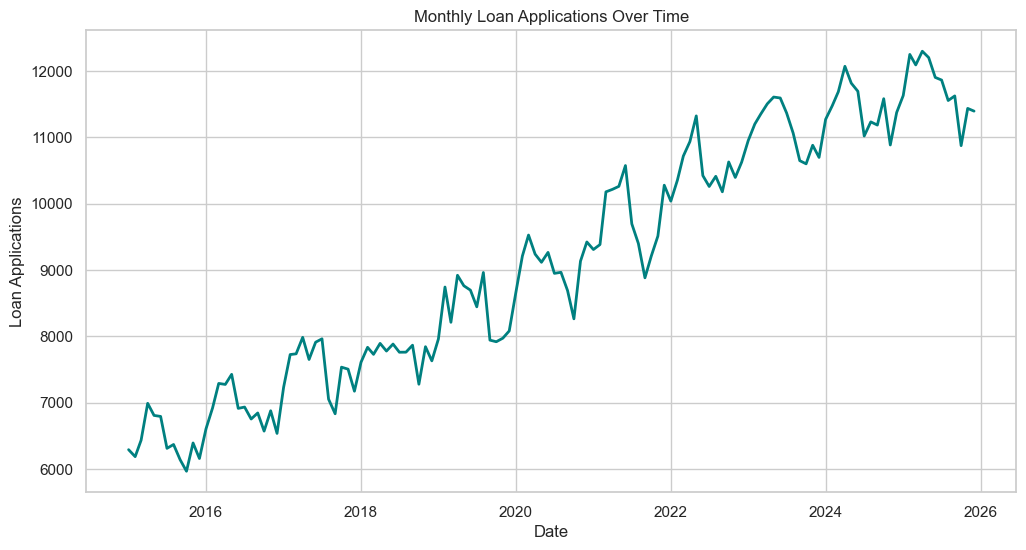

In [4]:
# Target Variable Plot
plt.figure()
sns.lineplot(data=df, x=df.index, y='Loan Applications', color='teal', linewidth=2)
plt.title('Monthly Loan Applications Over Time')
plt.xlabel('Date')
plt.ylabel('Loan Applications')
plt.show()

Plotting the primary demand metric reveals the structural velocity of loan applications over time.
Identifying structural breaks or periodic spikes during this stage informs whether non-stationary transformations
(first-differencing) will be required in the modeling phase.

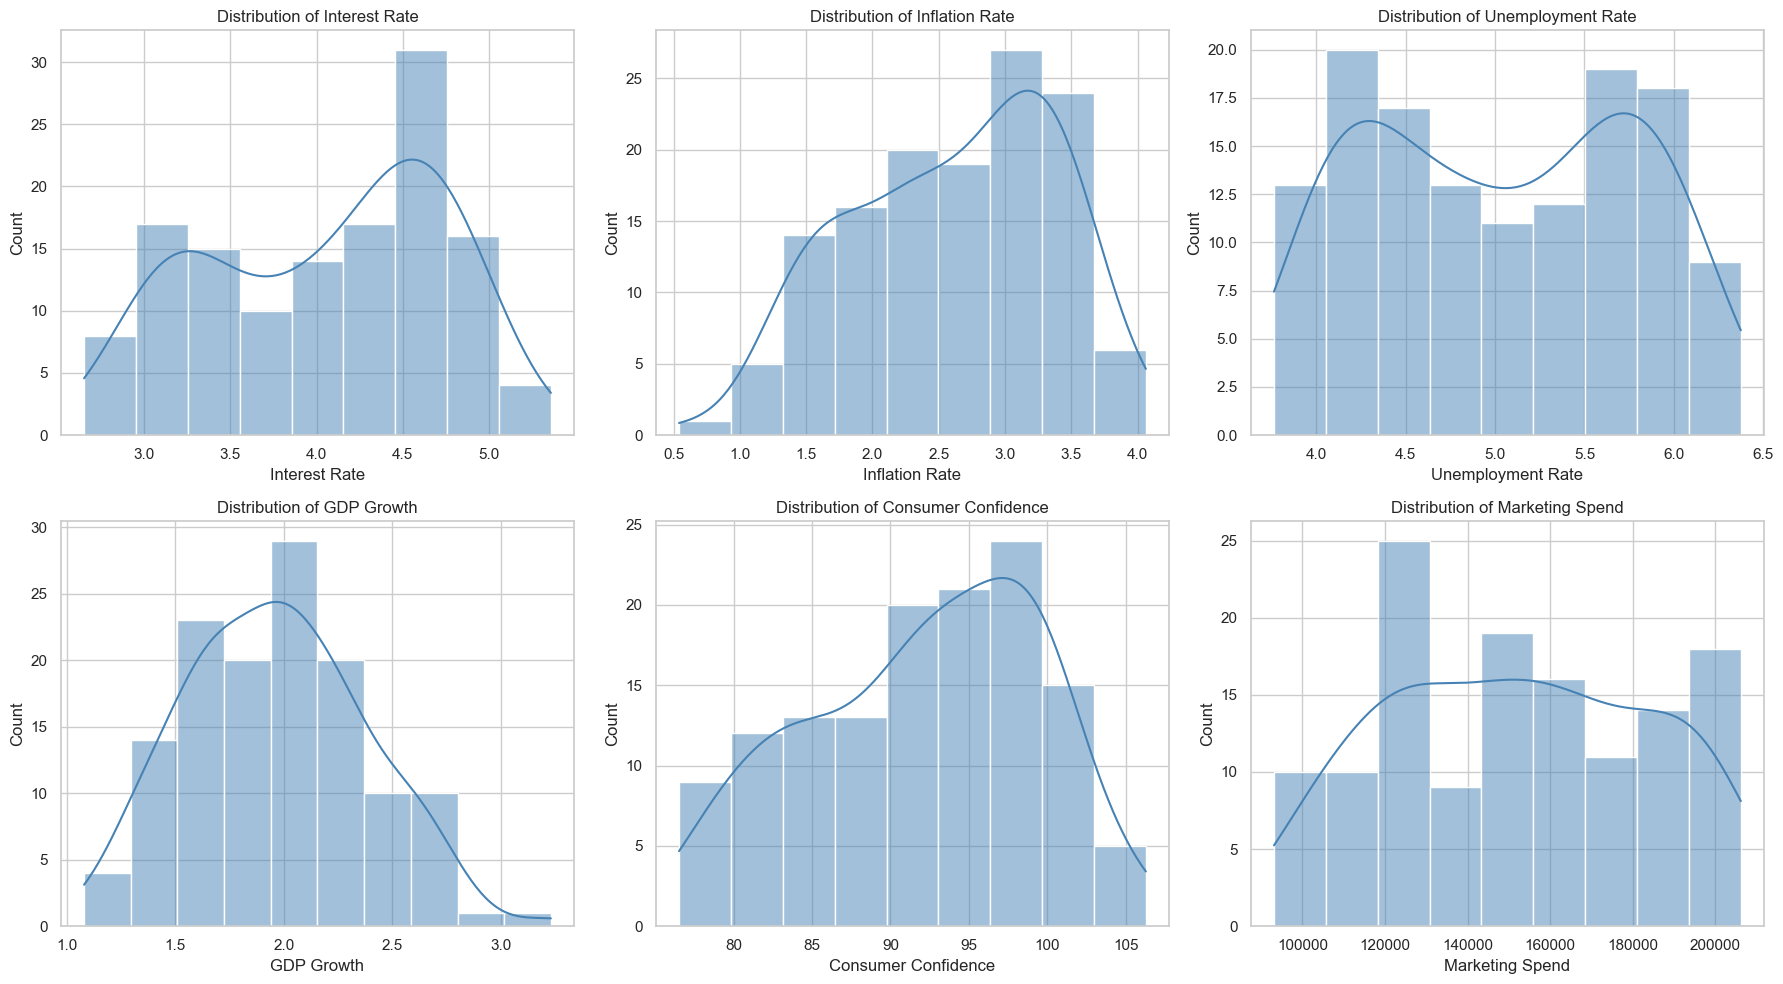

In [5]:
# Economic Factors Distributions
external_factors = ['Interest Rate', 'Inflation Rate', 'Unemployment Rate', 
                    'GDP Growth', 'Consumer Confidence', 'Marketing Spend']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, element in enumerate(external_factors):
    sns.histplot(data=df, x=element, ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f'Distribution of {element}')

plt.tight_layout()
plt.show()

In [6]:
# Export processed dataset
df.to_csv("processed_financial_forecasting_dataset.csv", index=False)